# Step 1 — Data Cleaning and Validation

**STW7085CEM Advanced Machine Learning — Task 1**  
**Title:** Bayesian Forecasting of Low-Visibility Events at Tribhuvan International Airport (VNKT, Kathmandu)  
**Student Name/ID:** Tek Raj Bhatt (250069)

## Purpose

Load the raw IEM ASOS-AWOS-METAR file for station VNKT, perform unit conversion, quality control, and feature extraction, and produce a cleaned hourly-resolution parquet file that downstream steps will consume.

All cleaning logic lives in `scripts/clean_metar.py` (kept out of the notebook so the same code can be cited verbatim in the paper's appendix and re-run from the command line). This notebook is the thin wrapper that calls it and produces sanity-check visualisations.

## Inputs and Outputs

| Path | Role |
|---|---|
| `data/raw/VNKT.csv`              | Input — raw IEM download (read-only) |
| `data/interim/vnkt_clean.parquet`| Output — cleaned hourly table |
| `reports/step1_validation.md`    | Output — validation summary |
| `reports/figures/step1_*.png`    | Output — sanity-check plots |


## 1. Imports and project paths

In [1]:
from pathlib import Path
import sys

# make `scripts/` importable from inside the notebook
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scripts.clean_metar import clean, setup_logging

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

RAW    = PROJECT_ROOT / 'data' / 'raw' / 'VNKT.csv'
OUT    = PROJECT_ROOT / 'data' / 'interim' / 'vnkt_clean.parquet'
REPORT = PROJECT_ROOT / 'reports' / 'step1_validation.md'
FIGDIR = PROJECT_ROOT / 'reports' / 'figures'
FIGDIR.mkdir(parents=True, exist_ok=True)

print('Project root:', PROJECT_ROOT)
print('Raw file exists:', RAW.exists())


Project root: /home/saggy/Desktop/advanced-ml-assignement
Raw file exists: True


## 2. Run the cleaning pipeline

A single call. All logic is in `scripts/clean_metar.py`. The function logs each stage to the console and writes both a parquet file and a Markdown report.

In [2]:
logger = setup_logging(verbose=True)
df = clean(RAW, OUT, REPORT, logger=logger)

print(f'\nCleaned dataframe shape: {df.shape}')
df.head()


[21:12:11] INFO    Loading raw file: /home/saggy/Desktop/advanced-ml-assignement/data/raw/VNKT.csv
[21:12:12] INFO      raw shape: (165040, 30)
[21:12:12] INFO      keeping 13 columns, dropping 17
[21:12:12] INFO    Converting units (°F→°C, miles→m, knots→m/s, inHg→hPa)...
[21:12:12] INFO    Ordinal-encoding sky cover (skyc1)...
[21:12:12] INFO    Extracting weather flags from wxcodes...
[21:12:12] INFO      fog (FG)  events: 295
[21:12:12] INFO      mist (BR) events: 23,572
[21:12:12] INFO    Decomposing wind into u/v components...
[21:12:12] INFO    Quality control: flagging out-of-range values...
[21:12:12] INFO      tempc          : nulled 1 out-of-range values
[21:12:12] INFO      dewpointc      : nulled 1 out-of-range values
[21:12:12] INFO      wind_speed_ms  : nulled 6 out-of-range values
[21:12:12] INFO      pressure_hpa   : nulled 60 out-of-range values
[21:12:12] INFO      dewpoint>temp:    capped 22 rows at temp value
[21:12:12] INFO    Wrote cleaned table: /home/saggy/Desk


Cleaned dataframe shape: (165040, 22)


,station,valid_utc,valid_npt,tempc,dewpointc,dewpoint_depression_c,relh,wind_speed_ms,wind_dir_deg,wind_u_ms,...,pressure_hpa,sky_cover_ord,cloud_base_m,visibility_m,wx_fog,wx_freezing_fog,wx_mist,wx_haze,wxcodes,metar
0,VNKT,2016-01-01 00:20:00+00:00,2016-01-01 06:05:00,5.0,4.0,1.0,93.24,0.000000,0.0,-0.000000,...,1024.044336,1,457.2,1995.58656,0,0,1,0,BR,VNKT 010020Z 00000KT 2000 BR FEW015 05/04 Q102...
1,VNKT,2016-01-01 00:50:00+00:00,2016-01-01 06:35:00,5.0,4.0,1.0,93.24,1.543332,150.0,-0.771666,...,1024.044336,1,457.2,1496.68992,0,0,1,0,BR,VNKT 010050Z 15003KT 1500 BR FEW015 05/04 Q102...
2,VNKT,2016-01-01 01:20:00+00:00,2016-01-01 07:05:00,4.0,3.0,1.0,93.19,1.543332,110.0,-1.450258,...,1025.060253,1,457.2,1496.68992,0,0,1,0,BR,VNKT 010120Z 11003KT 1500 BR FEW015 04/03 Q102...
3,VNKT,2016-01-01 01:50:00+00:00,2016-01-01 07:35:00,4.0,4.0,0.0,100.00,2.057776,80.0,-2.026514,...,1026.076170,1,457.2,1496.68992,0,0,1,0,BR,VNKT 010150Z 08004KT 1500 BR FEW015 04/04 Q102...
4,VNKT,2016-01-01 02:20:00+00:00,2016-01-01 08:05:00,6.0,5.0,1.0,93.30,1.543332,120.0,-1.336565,...,1026.076170,1,457.2,1496.68992,0,0,1,0,BR,VNKT 010220Z 12003KT 1500 BR FEW015 06/05 Q102...


## 3. Glance at the validation report

In [3]:
from IPython.display import Markdown
Markdown(REPORT.read_text())


# Step 1 Validation Report — VNKT METAR cleaning

- **Raw rows loaded**:           165,040
- **After deduplication**:       165,040
- **After quality control**:     165,040
- **Date range (NPT)**:       2016-01-01 06:05:00 → 2026-05-23 05:15:00

## Column completeness (% non-missing)

| Column | % present |
|---|---:|
| `station` | 100.00% |
| `wind_u_ms` | 100.00% |
| `wx_haze` | 100.00% |
| `wx_mist` | 100.00% |
| `wx_freezing_fog` | 100.00% |
| `wx_fog` | 100.00% |
| `sky_cover_ord` | 100.00% |
| `valid_utc` | 100.00% |
| `wind_v_ms` | 100.00% |
| `wind_calm` | 100.00% |
| `valid_npt` | 100.00% |
| `metar` | 100.00% |
| `wind_speed_ms` | 99.92% |
| `visibility_m` | 99.89% |
| `tempc` | 99.86% |
| `dewpointc` | 99.85% |
| `dewpoint_depression_c` | 99.84% |
| `cloud_base_m` | 99.82% |
| `relh` | 99.78% |
| `pressure_hpa` | 93.93% |
| `wind_dir_deg` | 76.69% |
| `wxcodes` | 30.66% |

## QC violations (out-of-range values replaced with NaN)

| Field | Violations |
|---|---:|
| `tempc` | 1 |
| `dewpointc` | 1 |
| `wind_speed_ms` | 6 |
| `pressure_hpa` | 60 |
| `dewpoint_gt_temp` | 22 |

## Weather code event counts

- Fog (`FG`)  events: **295**
- Mist (`BR`) events: **23,572**

## Hourly-level class distribution (winter Nov/Dec/Jan only)

_Total winter observations with valid visibility: 42,225_

| Class | Threshold | Count | Share |
|---|---|---:|---:|
| Diversions-Likely | vis < 800 m       | 125 | 0.30% |
| Delays-Likely     | 800 ≤ vis < 1600m | 1,121 | 2.65% |
| Normal            | vis ≥ 1600 m      | 40,979 | 97.05% |

_Note: the modelling table built in Step 2 will be at **daily** resolution (next-morning 05:45–09:45 NPT minimum visibility per day), where the Diversions-Likely class rises to ~3.4% — an imbalance that is workable for ML._

## 4. Sanity-check plots

These figures are the visual gate before we go anywhere near a model. If anything here looks wrong, stop and fix it.

### 4.1 Visibility distribution (winter vs rest-of-year)

Expectation: winter has a long left tail down toward zero; non-winter is concentrated near the 10 km IEM ceiling.

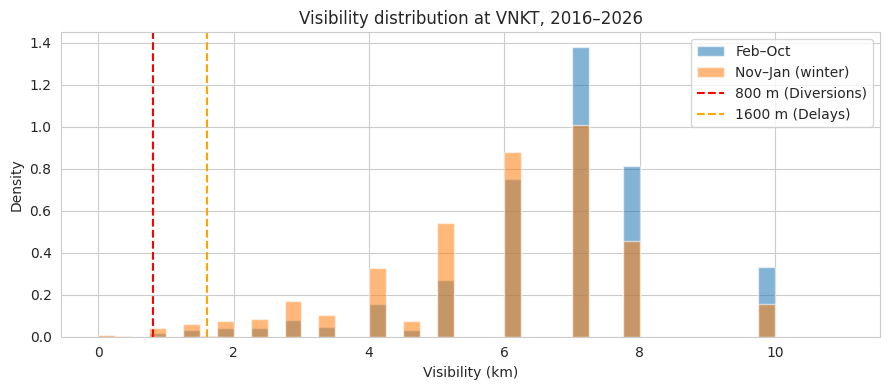

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(9, 4))

winter_mask = df['valid_npt'].dt.month.isin([11, 12, 1])
vis_winter  = df.loc[ winter_mask, 'visibility_m'].dropna() / 1000
vis_other   = df.loc[~winter_mask, 'visibility_m'].dropna() / 1000

bins = np.linspace(0, 11, 45)
ax.hist(vis_other,  bins=bins, alpha=0.55, label='Feb–Oct', density=True)
ax.hist(vis_winter, bins=bins, alpha=0.55, label='Nov–Jan (winter)', density=True)
ax.axvline(0.8,  ls='--', color='red',    label='800 m (Diversions)')
ax.axvline(1.6,  ls='--', color='orange', label='1600 m (Delays)')
ax.set_xlabel('Visibility (km)')
ax.set_ylabel('Density')
ax.set_title('Visibility distribution at VNKT, 2016–2026')
ax.legend()
fig.tight_layout()
fig.savefig(FIGDIR / 'step1_visibility_distribution.png', dpi=120)
plt.show()


### 4.2 Time-of-day pattern of low visibility

Expectation: fog and low visibility peak in the early morning (05:45–09:00 NPT per Chapagain et al. 2024). If this pattern is absent, either the NPT conversion is wrong or the data is corrupted.

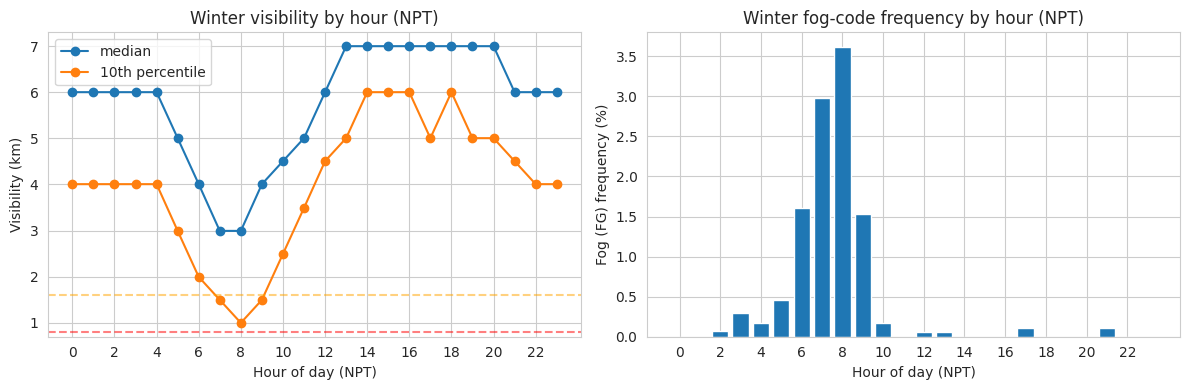

Peak fog frequency expected at NPT hours 5–9. Observed peak at: 8 NPT


In [5]:
winter = df[df['valid_npt'].dt.month.isin([11, 12, 1])].copy()
winter['hour_npt'] = winter['valid_npt'].dt.hour

hourly = winter.groupby('hour_npt').agg(
    median_vis_m=('visibility_m', 'median'),
    p10_vis_m=('visibility_m', lambda s: s.quantile(0.10)),
    fog_rate=('wx_fog', 'mean'),
).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(hourly['hour_npt'], hourly['median_vis_m']/1000, marker='o', label='median')
ax1.plot(hourly['hour_npt'], hourly['p10_vis_m']/1000,    marker='o', label='10th percentile')
ax1.axhline(1.6, ls='--', color='orange', alpha=0.5)
ax1.axhline(0.8, ls='--', color='red',    alpha=0.5)
ax1.set_xlabel('Hour of day (NPT)')
ax1.set_ylabel('Visibility (km)')
ax1.set_title('Winter visibility by hour (NPT)')
ax1.legend()
ax1.set_xticks(range(0, 24, 2))

ax2.bar(hourly['hour_npt'], hourly['fog_rate'] * 100)
ax2.set_xlabel('Hour of day (NPT)')
ax2.set_ylabel('Fog (FG) frequency (%)')
ax2.set_title('Winter fog-code frequency by hour (NPT)')
ax2.set_xticks(range(0, 24, 2))

fig.tight_layout()
fig.savefig(FIGDIR / 'step1_diurnal_cycle.png', dpi=120)
plt.show()

print('Peak fog frequency expected at NPT hours 5–9. Observed peak at:',
      int(hourly.loc[hourly['fog_rate'].idxmax(), 'hour_npt']), 'NPT')


### 4.3 Correlation of cleaned numeric features

Expectation: dew-point depression should correlate negatively with relative humidity (mechanically — they encode the same physical quantity in different units) and negatively with the fog flag. Visibility should correlate positively with dew-point depression and negatively with humidity.

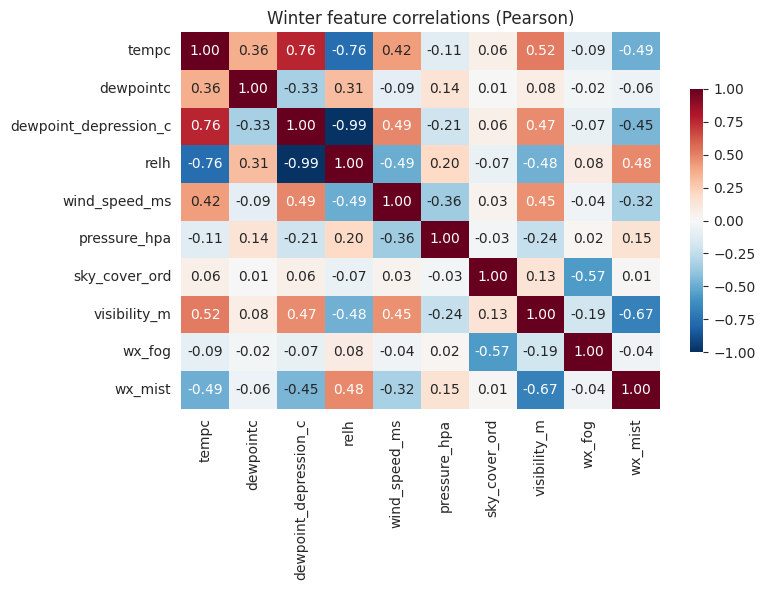

In [6]:
numeric_cols = [
    'tempc', 'dewpointc', 'dewpoint_depression_c', 'relh',
    'wind_speed_ms', 'pressure_hpa', 'sky_cover_ord',
    'visibility_m', 'wx_fog', 'wx_mist',
]
corr = df[df['valid_npt'].dt.month.isin([11, 12, 1])][numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, ax=ax, cbar_kws={'shrink': 0.7})
ax.set_title('Winter feature correlations (Pearson)')
fig.tight_layout()
fig.savefig(FIGDIR / 'step1_correlation_heatmap.png', dpi=120)
plt.show()


### 4.4 Time-coverage check

Expectation: roughly constant observation density across all 11 winter seasons. Any large gap is a data-source problem we need to know about before modelling.

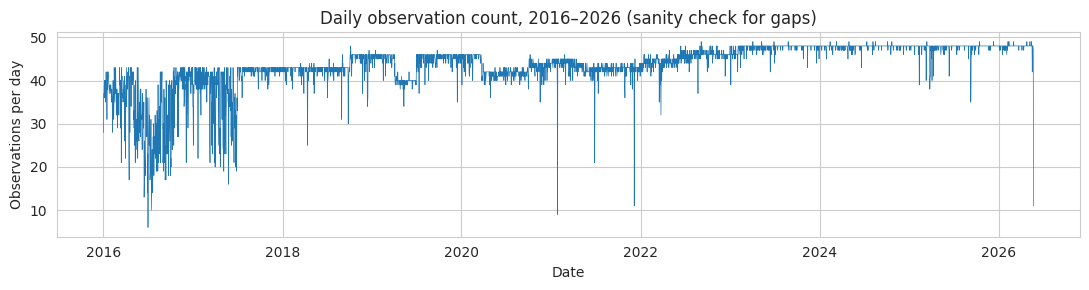

Days with no observations: 1


In [7]:
df['date_npt'] = df['valid_npt'].dt.date
daily_obs = df.groupby('date_npt').size().rename('n_obs').reset_index()
daily_obs['date_npt'] = pd.to_datetime(daily_obs['date_npt'])

fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(daily_obs['date_npt'], daily_obs['n_obs'], lw=0.5)
ax.set_ylabel('Observations per day')
ax.set_xlabel('Date')
ax.set_title('Daily observation count, 2016–2026 (sanity check for gaps)')
fig.tight_layout()
fig.savefig(FIGDIR / 'step1_daily_coverage.png', dpi=120)
plt.show()

print(f'Days with no observations: '
      f'{(pd.date_range(daily_obs.date_npt.min(), daily_obs.date_npt.max()).size - len(daily_obs)):,}')


## 5. Output summary

What we now have on disk and what the next step expects to consume.

In [8]:
outputs = {
    'Cleaned parquet':       OUT,
    'Validation report':     REPORT,
    'Visibility distribution': FIGDIR / 'step1_visibility_distribution.png',
    'Diurnal cycle':         FIGDIR / 'step1_diurnal_cycle.png',
    'Correlation heatmap':   FIGDIR / 'step1_correlation_heatmap.png',
    'Daily coverage':        FIGDIR / 'step1_daily_coverage.png',
}

for name, path in outputs.items():
    status = '✓' if path.exists() else '✗ MISSING'
    size_kb = path.stat().st_size / 1024 if path.exists() else 0
    print(f'{status}  {name:25s}  {path}  ({size_kb:,.0f} KB)')

print(f'\nFinal cleaned dataframe: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Date range (NPT): {df.valid_npt.min()} -> {df.valid_npt.max()}')


✓  Cleaned parquet            /home/saggy/Desktop/advanced-ml-assignement/data/interim/vnkt_clean.parquet  (6,966 KB)
✓  Validation report          /home/saggy/Desktop/advanced-ml-assignement/reports/step1_validation.md  (2 KB)
✓  Visibility distribution    /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step1_visibility_distribution.png  (39 KB)
✓  Diurnal cycle              /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step1_diurnal_cycle.png  (66 KB)
✓  Correlation heatmap        /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step1_correlation_heatmap.png  (144 KB)
✓  Daily coverage             /home/saggy/Desktop/advanced-ml-assignement/reports/figures/step1_daily_coverage.png  (67 KB)

Final cleaned dataframe: 165,040 rows × 23 columns
Date range (NPT): 2016-01-01 06:05:00 -> 2026-05-23 05:15:00


---

## Next step

**Step 2 — Feature Engineering and Daily Aggregation.** We will take this hourly cleaned table and turn it into the final ~1,300-row **daily** modelling table that the Gaussian Process and Random Forest will be fitted on. The aggregation rule: for each target date *D*, the target visibility is the minimum visibility observed in the 05:45–09:45 NPT window on *D*; the features are derived from the **prior night** (*D*−1, 18:00 → *D*, 05:45 NPT) so the model only uses information that would actually be available the evening before a flight.